In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
pd.options.display.max_rows=2000

In [3]:
#constants
base_path='../data/clean'
palette = ['#4C78A8', '#F58518', '#E45756', '#72B7B2', '#54A24B']
#palette = sns.color_palette('Set2', n_colors=5)

In [4]:
#read cleaned data
products_df=pd.read_csv(f'{base_path}/products_cl.csv')
orders_df=pd.read_csv(f'{base_path}/orders_cl.csv')
brands_df=pd.read_csv(f'{base_path}/brands_cl.csv')
orderlines_df=pd.read_csv(f'{base_path}/orderlines_cl.csv')

In [5]:
orders_df['created_date']=pd.to_datetime(orders_df['created_date'])

In [6]:
orderlines_df['date']=pd.to_datetime(orderlines_df['date'])

### Discounts analysis

In [7]:
# Discount is the diffrence between the unit_price in orderlines and price in products
# we need to merge this two table together

In [8]:
products_df['sku'].nunique()

9992

In [9]:
orderlines_df['sku'].nunique()

5098

In [10]:
orderlines_df

,id,id_order,product_id,product_quantity,sku,unit_price,date
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50
...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35


In [11]:
ol_p_df=orderlines_df.merge(products_df,on='sku',how='left')

In [12]:
ol_p_df

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404
...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230


In [13]:
ol_p_df.drop(['id','product_id','in_stock'],axis=1,inplace=True)

In [14]:
ol_p_df.rename(columns={'product_quantity':'qty','id_order':'order_id'},inplace=True)

In [15]:
ol_p_df.rename(columns={'unit_price':'sale_price','price':'base_price'},inplace=True)

In [16]:
ol_p_df=ol_p_df[['date','order_id','sku','name','desc','qty','base_price','sale_price']]

In [17]:
ol_p_df.loc[:,'discount']=ol_p_df['base_price']-ol_p_df['sale_price']

In [18]:
ol_p_df.loc[:,'discount_rate']=round(ol_p_df['discount']/ol_p_df['base_price'],3)

In [19]:
ol_p_df.loc[:,'date']=ol_p_df['date'].dt.date

In [20]:
ol_p_df.loc[:,'is_discounted']=True
ol_p_df.loc[ol_p_df['sale_price']>=ol_p_df['base_price'],'is_discounted']=False

In [21]:
ol_p_df.loc[:,'total_sale_price']=ol_p_df['sale_price']*ol_p_df['qty']

#### What is the time period that the dataset covers?

In [22]:
min_date=ol_p_df['date'].min().date()
max_date=ol_p_df['date'].max().date()

print(f'The dataset covers from {min_date} to {max_date}')

The dataset covers from 2017-01-01 to 2018-03-14


#### What is the overall revenue for that time?

In [23]:
overall_revenue=float(round((ol_p_df['qty']*ol_p_df['sale_price']).sum(),1))
overall_revenue

7817204.4

#### How many orders are there? How many items have been sold?

In [24]:
orders_df['order_id'].nunique()

40985

In [25]:
orderlines_df['product_quantity'].sum()

np.int64(60011)

#### Do discounted products lead to more sales ?

In [26]:
discounted_p=ol_p_df.groupby('is_discounted').agg(total_unit_sold=('qty','sum')).reset_index()
discounted_p['is_discounted'] = discounted_p['is_discounted'].map({
    True: 'With Discount',
    False: 'Without Discount'
})
total_units=discounted_p['total_unit_sold'].sum()
discounted_p['percentage'] = (discounted_p['total_unit_sold'] /total_units  * 100).round(1)

In [27]:
discounted_p

,is_discounted,total_unit_sold,percentage
0,Without Discount,4341,7.2
1,With Discount,55670,92.8


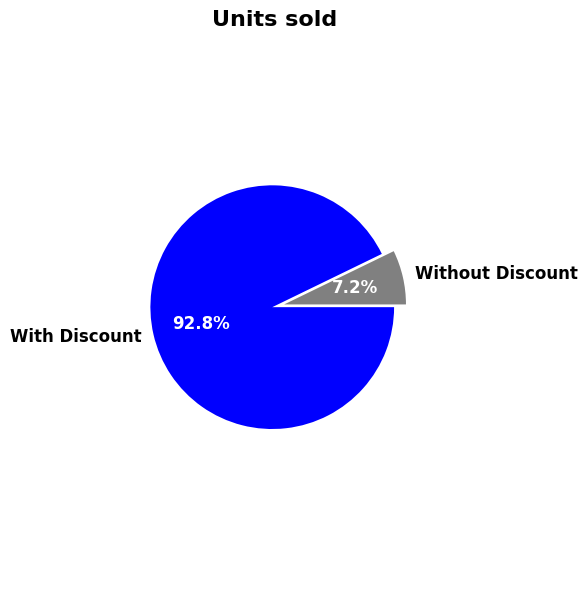

In [28]:
labels = list(discounted_p['is_discounted'])
sizes = [7.2,92.8]
colors = ['gray', 'blue']
explode = (0.05, 0.05)  

# Create the pie chart
plt.figure(figsize=(6, 6))
patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',

    colors=colors,
    explode=explode,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# Make text more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

plt.title('Units sold ', fontsize=16, weight='bold')
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
plt.tight_layout()
plt.savefig('/Users/yazdan/Desktop/plots/unit_sold.png', dpi=300, bbox_inches='tight')


#### Do discounted products generate more or less total revenue?

In [29]:
discounted_r=ol_p_df.groupby('is_discounted').agg(total_revenue=('total_sale_price','sum')).reset_index()

In [30]:
discounted_r['is_discounted'] = discounted_r['is_discounted'].map({
    True: 'With Discount',
    False: 'Without Discount'
})
total_revenue=discounted_r['total_revenue'].sum()
discounted_r['percentage'] = (discounted_r['total_revenue'] /total_revenue  * 100).round(1)

In [31]:
discounted_r

,is_discounted,total_revenue,percentage
0,Without Discount,575080.98,7.4
1,With Discount,7242123.42,92.6


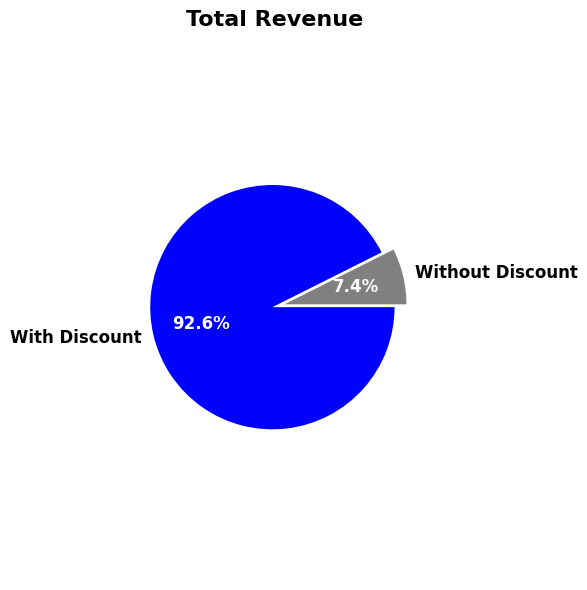

In [32]:
labels = list(discounted_r['is_discounted'])
sizes = [7.4,92.6]
colors = ['gray', 'blue']
explode = (0.05, 0.05)  

# Create the pie chart
plt.figure(figsize=(6, 6))
patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',

    colors=colors,
    explode=explode,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# Make text more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

plt.title('Total Revenue ', fontsize=16, weight='bold')
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
plt.tight_layout()
plt.savefig('/Users/yazdan/Desktop/plots/revenue.png', dpi=300, bbox_inches='tight')

#### How big are the offered discounts as a percentage of the product prices?


In [33]:
float(round(ol_p_df['discount_rate'].mean(),2))

0.21

#### What are the most sold products? are they discounted or not? how is the discount rate of them?


In [77]:
top_5_sold_p=ol_p_df.groupby(['sku','name','is_discounted']).agg(total_unit_sold=('qty','count'),avg_discount_rate=('discount_rate','mean')).nlargest(5,'total_unit_sold')

In [78]:
top_5_sold_p

,,,total_unit_sold,avg_discount_rate
sku,name,is_discounted,,
APP1190,IPhone AppleCare Protection Plan,True,860,0.224103
APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),True,478,0.599979
APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,True,449,0.113960
APP0927,EarPods Apple Headphones with Remote and Mic (OEM),True,378,0.509794
SAM0074,Samsung 850 EVO SSD Disk 500GB,True,298,0.152453


In [81]:
top_5_sold_p['name_refactor']=['IPhone Protection','Apple Lightning Cable','Apple AirPods','Apple EarPods','Samsung 500GB SSD']

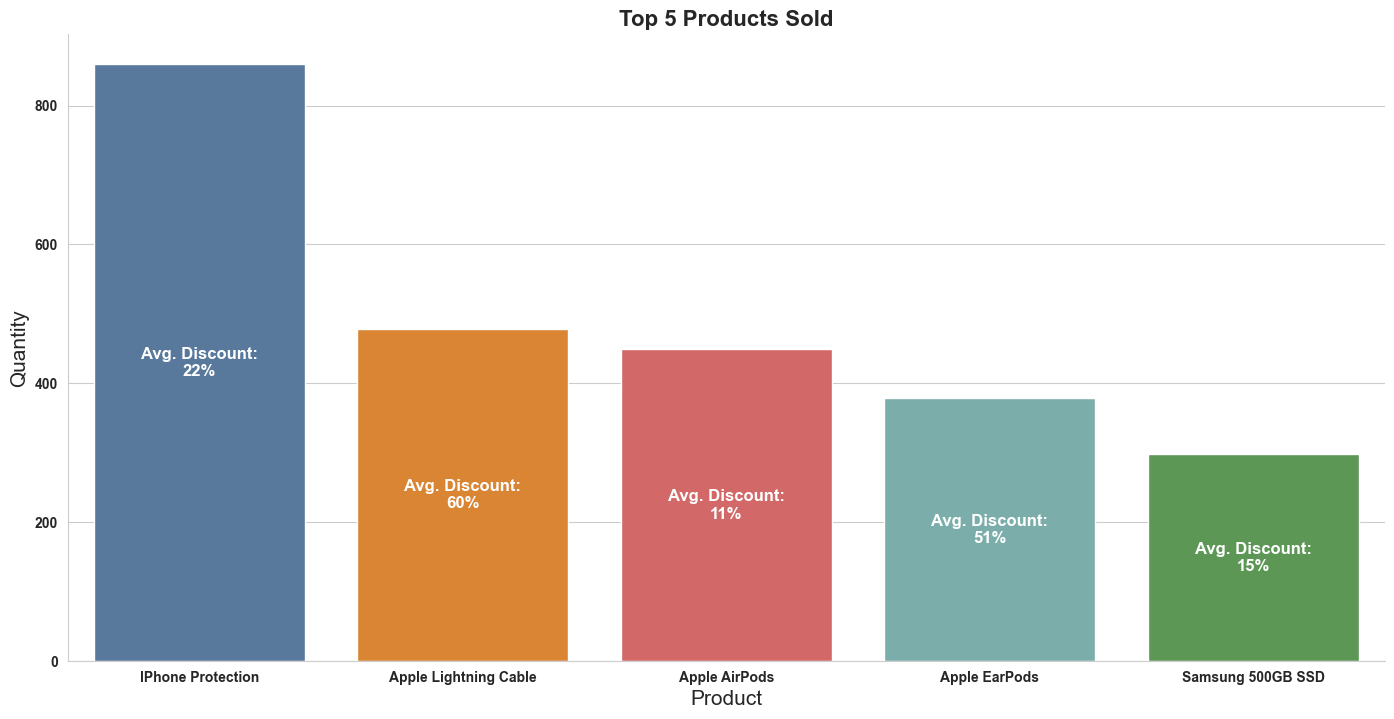

In [84]:
sns.set_style('whitegrid')

# Create the bar plot
ax = sns.catplot(
    data=top_5_sold_p,
    y='total_unit_sold',
    x='name_refactor',
    kind='bar',
    hue='name_refactor',
    palette=palette,
    height=7,
    aspect=2
)

# Add title and axis labels
plt.title("Top 5 Products Sold", fontsize=16, fontweight='bold')
plt.xlabel("Product", fontsize=15)
plt.ylabel("Quantity", fontsize=15)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Annotate bars with discount rates
for i, bar in enumerate(ax.ax.patches):
    discount = top_5_sold_p.iloc[i]['avg_discount_rate']
    height = bar.get_height()
    ax.ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,  # Middle of the bar
        f'Avg. Discount:\n{discount * 100:.0f}%',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='white'  # better visibility inside blue bar
    )
plt.savefig('/Users/yazdan/Desktop/plots/top_5_p_by_sold.png', dpi=300, bbox_inches='tight')

#### What are the products that generate the most revenue? Are they discounted or not?

In [36]:
top_5_p=ol_p_df.groupby(['sku','name','is_discounted']).agg(total_revenue=('total_sale_price','sum'),avg_discount_rate=('discount_rate','mean')).nlargest(5,'total_revenue')

In [37]:
top_5_p

,,,total_revenue,avg_discount_rate
sku,name,is_discounted,,
LGE0044,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",True,133575.86,0.053793
APP2446,Apple iPhone 6 32GB Space Gray,True,104560.64,0.137908
APP2477,Apple iPhone 64GB Space Gray 8,True,85301.93,0.023520
APP1970,Apple iPhone 32GB Space Gray,True,80715.76,0.135859
APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,True,75196.26,0.113960


In [79]:
top_5_p['name_refactor']=['LG Monitor 27UD88-W','Apple iPhone 6 32GB','Apple iPhone 7 64GB ','Apple iPhone 7 32GB','Apple AirPods']

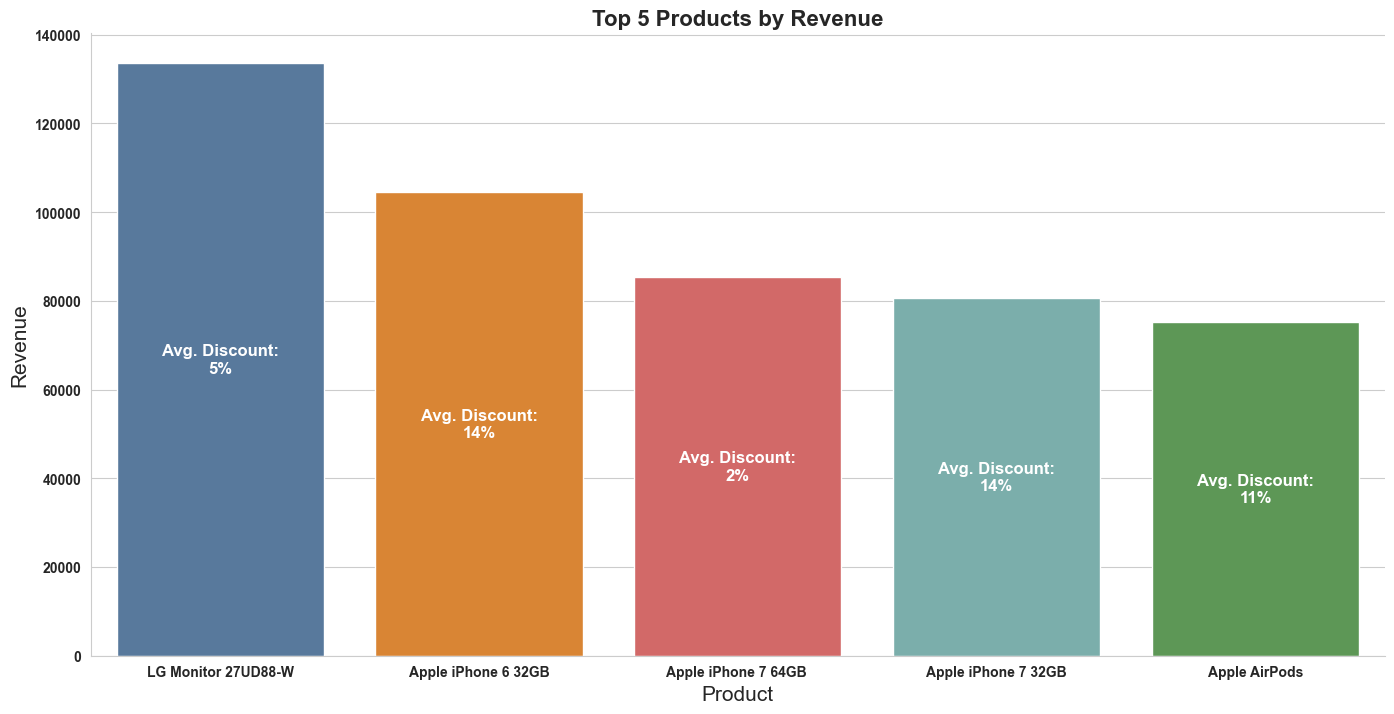

In [80]:
sns.set_style('whitegrid')
# Create the bar plot
ax = sns.catplot(
    data=top_5_p,
    y='total_revenue',
    x='name_refactor',
    kind='bar',
    palette=palette,
    hue='name_refactor',
    height=7,
    aspect=2
)

# Add title and axis labels
plt.title("Top 5 Products by Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Product", fontsize=15)
plt.ylabel("Revenue", fontsize=15)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Annotate bars with discount rates
for i, bar in enumerate(ax.ax.patches):
    discount = top_5_p.iloc[i]['avg_discount_rate']
    height = bar.get_height()
    ax.ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,  # Middle of the bar
        f'Avg. Discount:\n{discount * 100:.0f}%',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='white'  # better visibility inside blue bar
    )
plt.savefig('/Users/yazdan/Desktop/plots/top_5_p_by_rev.png', dpi=300, bbox_inches='tight')

#### Are there seasonal patterns in the evolution of sales?

In [39]:
ol_p_df.loc[:,'year']=ol_p_df['date'].dt.year
ol_p_df.loc[:,'month']=ol_p_df['date'].dt.month
ol_p_df.loc[:,'weekday']=ol_p_df['date'].dt.weekday

In [40]:
ol_p_df

,date,order_id,sku,name,desc,qty,base_price,sale_price,discount,discount_rate,is_discounted,total_sale_price,year,month,weekday
0,2017-01-01,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,1,60.99,47.49,13.50,0.221,True,47.49,2017,1,6
1,2017-01-01,299546,IOT0014,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,1,22.95,18.99,3.96,0.173,True,18.99,2017,1,6
2,2017-01-01,295347,APP0700,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,1,89.00,72.19,16.81,0.189,True,72.19,2017,1,6
3,2017-01-01,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,1,76.99,60.90,16.09,0.209,True,60.90,2017,1,6
4,2017-01-01,299561,PEB0015,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,1,299.99,142.49,157.50,0.525,True,142.49,2017,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53226,2018-03-14,527035,APP0698,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,1,25.00,9.99,15.01,0.600,True,9.99,2018,3,2
53227,2018-03-14,527070,APP0698,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,2,25.00,9.99,15.01,0.600,True,19.98,2018,3,2
53228,2018-03-14,527074,APP0698,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,2,25.00,9.99,15.01,0.600,True,19.98,2018,3,2
53229,2018-03-14,527096,APP0698,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,3,25.00,9.99,15.01,0.600,True,29.97,2018,3,2


In [63]:
month_by_sale=ol_p_df.resample('MS',on='date').agg(count_sold_products=('qty','sum'),total_revenue=('total_sale_price','sum'),avg_discount=('discount_rate','mean'))

In [64]:
month_by_sale

,count_sold_products,total_revenue,avg_discount
date,,,
2017-01-01,6855,609260.70,0.248035
2017-02-01,2918,327483.46,0.196102
2017-03-01,246,25508.97,0.189536
2017-04-01,2132,230379.32,0.182921
2017-05-01,2573,331725.55,0.153029
2017-06-01,2051,285107.03,0.174128
2017-07-01,4625,603124.23,0.249030
2017-08-01,3023,376329.62,0.205311
2017-09-01,2788,393137.39,0.201150


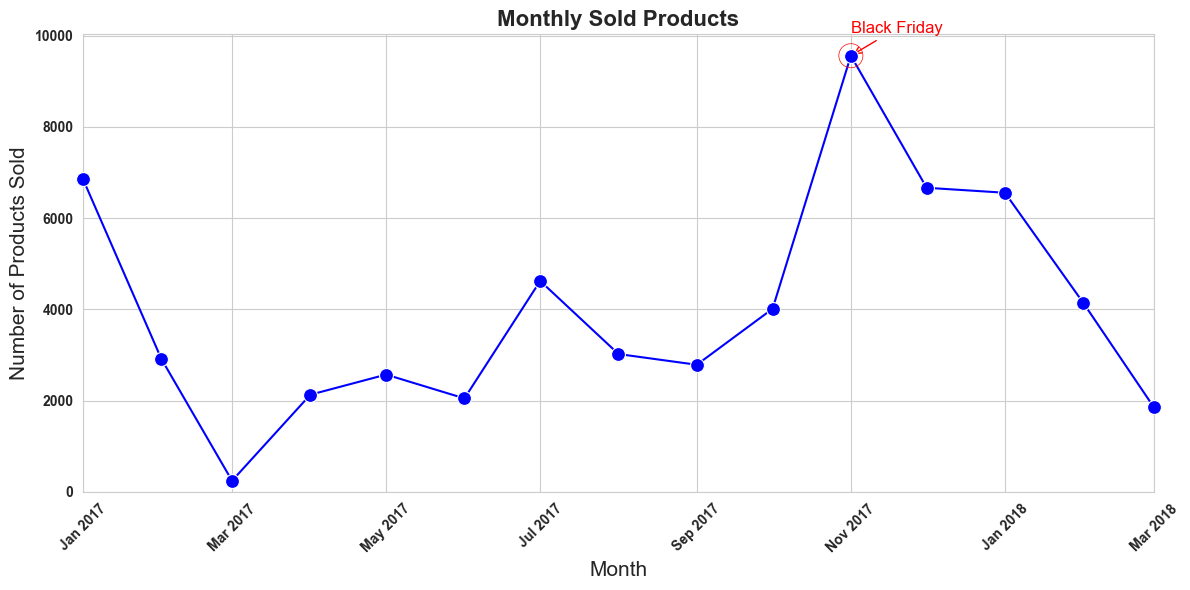

In [67]:
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

# Plot the line (no markers)
ax=sns.lineplot(
    data=month_by_sale,
    x='date',
    y='count_sold_products',
    color='blue',
)

# Plot the markers separately
sns.scatterplot(
    data=month_by_sale,
    x='date',
    y='count_sold_products',
    color='blue',   # Marker color
    s=100,         # Marker size
    zorder=10,      # Draw on top of the line
    clip_on=False
)

# Find the max row in your DataFrame
max_row = month_by_sale.loc[month_by_sale['count_sold_products'].idxmax()]
max_date = max_row.name  # index should be datetime (after resample)
max_value = max_row['count_sold_products']
# Plot the circle around the max point
plt.scatter(
    [max_date], [max_value],
    s=300,           # Bigger size for the outer circle
    facecolors='none',
    edgecolors='red',
    linewidths= .5,
    zorder=10
)

# Annotate the point
plt.annotate(
    'Black Friday',
    xy=(max_date, max_value),
    xytext=(max_date, max_value + 500),  # Adjust label position above point
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=12,
    color='red',
    ha='left'
)

# Axis formatting

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title("Monthly Sold Products", fontsize=16,fontweight='bold')
plt.xlabel("Month",fontsize=15)
plt.ylabel("Number of Products Sold",fontsize=15)
plt.xticks(rotation=45,fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlim(pd.to_datetime('2017-01-01'), pd.to_datetime('2018-03-01')) 
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig('/Users/yazdan/Desktop/plots/sold_products_by_month.png', dpi=300, bbox_inches='tight')

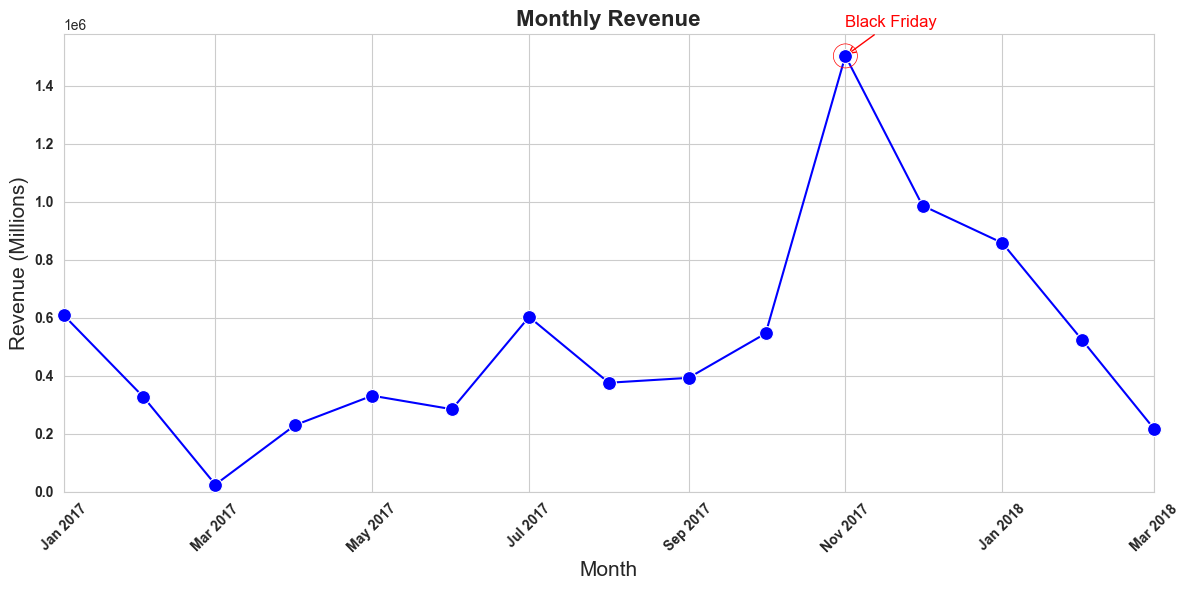

In [44]:
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

# Plot the line (no markers)
ax=sns.lineplot(
    data=month_by_sale,
    x='date',
    y='total_revenue',
    color='blue',
)

# Plot the markers separately
sns.scatterplot(
    data=month_by_sale,
    x='date',
    y='total_revenue',
    color='blue',   # Marker color
    s=100,         # Marker size
    zorder=10,      # Draw on top of the line
    clip_on=False
)

# Find the max row in your DataFrame
max_row = month_by_sale.loc[month_by_sale['total_revenue'].idxmax()]
max_date = max_row.name  # index should be datetime (after resample)
max_value = max_row['total_revenue']
# Plot the circle around the max point
plt.scatter(
    [max_date], [max_value],
    s=300,           # Bigger size for the outer circle
    facecolors='none',
    edgecolors='red',
    linewidths= .5,
    zorder=10
)

# Annotate the point
plt.annotate(
    'Black Friday',
    xy=(max_date, max_value),
    xytext=(max_date, max_value + 100000),  # Adjust label position above point
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=12,
    color='red',
    ha='left'
)

# Axis formatting

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title("Monthly Revenue", fontsize=16,fontweight='bold')
plt.xlabel("Month",fontsize=15)
plt.ylabel("Revenue (Millions)",fontsize=15)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.ylim(bottom=0)
plt.xticks(rotation=45,fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlim(pd.to_datetime('2017-01-01'), pd.to_datetime('2018-03-01'))  
plt.tight_layout()
plt.savefig('/Users/yazdan/Desktop/plots/revenue_by_month.png', dpi=300, bbox_inches='tight')

#### How should products be classified into different categories to simplify reports and analysis?


In [45]:
ol_p_df.loc[:,'category']=''

In [46]:
ol_p_df.loc[ol_p_df["desc"].str.contains("keyboard", case=False), "category"] += ", keyboard"
ol_p_df.loc[ol_p_df["name"].str.contains("^.{0,7}apple iphone", case=False), "category"] += ", smartphone"
ol_p_df.loc[ol_p_df["name"].str.contains("^.{0,7}apple ipod", case=False), "category"] += ", ipod"
ol_p_df.loc[ol_p_df["name"].str.contains("^.{0,7}apple ipad|tablet", case=False), "category"] += ", tablet"
ol_p_df.loc[ol_p_df["name"].str.contains("imac|mac mini|mac pro", case=False), "category"] += ", desktop"
ol_p_df.loc[ol_p_df["name"].str.contains("macbook", case=False), "category"] += ", laptop"
ol_p_df.loc[ol_p_df["desc"].str.contains("backpack", case=False), "category"] += ", backpack"
ol_p_df.loc[ol_p_df["desc"].str.contains("case|funda|housing|casing|folder", case=False), "category"] += ", case"
ol_p_df.loc[ol_p_df["desc"].str.contains("dock|hub|connection|expansion box", case=False), "category"] += ", dock"
ol_p_df.loc[ol_p_df["desc"].str.contains("cable|connector|lightning to usb|wall socket|power strip", case=False), "category"] += ", cable"
ol_p_df.loc[ol_p_df["desc"].str.contains("flash drive|hard drive|pendrive|hard disk|memory|storage|^ssd|^hardssd|modules|ssd expansion", case=False), "category"] = ", storage"
ol_p_df.loc[ol_p_df["desc"].str.contains("battery", case=False), "category"] += ", battery"
ol_p_df.loc[ol_p_df["desc"].str.contains("headset|headphones", case=False), "category"] += ", headset"
ol_p_df.loc[ol_p_df["desc"].str.contains("charger", case=False), "category"] += ", charger"
ol_p_df.loc[ol_p_df["desc"].str.contains("mouse|trackpad", case=False), "category"] += ", mouse"
ol_p_df.loc[ol_p_df["desc"].str.contains("stand|support", case=False), "category"] += ", stand"
ol_p_df.loc[ol_p_df["desc"].str.contains("strap|armband|belt|bracelet", case=False), "category"] += ", strap"
ol_p_df.loc[ol_p_df["desc"].str.contains("^.{0,6}apple watch|smartwatch|smart watch", case=False), "category"] += ", smartwatch"
ol_p_df.loc[ol_p_df["desc"].str.contains("adapter", case=False), "category"] += ", adapter"
ol_p_df.loc[ol_p_df["desc"].str.contains("^.{0,7}ram", case=False), "category"] += ", ram"
ol_p_df.loc[ol_p_df["desc"].str.contains("protect|cover|sleeve|screensaver|shell", case=False), "category"] += ", protection"
ol_p_df.loc[ol_p_df["desc"].str.contains("nas|server|raid|synology", case=False), "category"] += ", server"
ol_p_df.loc[ol_p_df["desc"].str.contains("scale", case=False), "category"] += ", scale"
ol_p_df.loc[ol_p_df["desc"].str.contains("thermometer", case=False), "category"] += ", thermometer"
ol_p_df.loc[ol_p_df["desc"].str.contains("monitor", case=False), "category"] += ", monitor"
ol_p_df.loc[ol_p_df["desc"].str.contains("speaker|music system", case=False), "category"] += ", speaker"
ol_p_df.loc[ol_p_df["desc"].str.contains("camera", case=False), "category"] += ", camera"
ol_p_df.loc[ol_p_df["desc"].str.contains("pointer", case=False), "category"] += ", pointer"
ol_p_df.loc[ol_p_df["desc"].str.contains("refurbished|reconditioned|like new", case=False), "category"] += ", refurbished"

In [47]:
ol_p_df.loc[ol_p_df["category"] == "", "category"] += ", other"

In [48]:
ol_p_df["category"] = ol_p_df["category"].str[2:]

ol_p_df["category"].value_counts()

category
storage                                      8110
other                                        7122
ram                                          2762
protection                                   2488
case                                         2065
cable                                        1956
adapter                                      1916
smartphone                                   1886
headset                                      1811
monitor                                      1247
storage, server                              1151
dock                                         1097
tablet                                       1088
battery                                       965
server                                        944
laptop, battery                               940
desktop                                       931
laptop                                        788
case, protection                              724
speaker                                  

In [49]:
ol_p_df[ol_p_df['category']=='storage']['is_discounted'].value_counts()

is_discounted
True     7688
False     422
Name: count, dtype: int64

In [50]:
ol_p_df[ol_p_df['category']=='storage']['discount_rate'].mean()

np.float64(0.17948532675709)

In [51]:
category_agg=ol_p_df.groupby('category').agg(
    total_sold_quantity=('qty','sum'),
    total_revenue=('total_sale_price','sum'),
    average_discount_rate=('discount_rate','mean'),
    
                               ).nlargest(20,'total_revenue')

In [52]:
category_agg

,total_sold_quantity,total_revenue,average_discount_rate
category,,,
storage,9528,1338825.12,0.179485
smartphone,1938,1113919.51,0.067329
other,8053,640726.35,0.188855
monitor,1496,447361.93,0.211804
tablet,1199,423343.51,0.133294
server,971,366396.58,0.086845
"storage, server",1726,349632.29,0.169454
ram,3341,315933.05,0.142146
refurbished,543,239897.37,0.228912


In [53]:
top_5_cat=category_agg.loc[['storage','smartphone','monitor','tablet','server']]

In [54]:
top_5_cat

,total_sold_quantity,total_revenue,average_discount_rate
category,,,
storage,9528,1338825.12,0.179485
smartphone,1938,1113919.51,0.067329
monitor,1496,447361.93,0.211804
tablet,1199,423343.51,0.133294
server,971,366396.58,0.086845


In [55]:
top_5_cat.index = top_5_cat.index.str.capitalize()

In [56]:
top_5_cat

,total_sold_quantity,total_revenue,average_discount_rate
category,,,
Storage,9528,1338825.12,0.179485
Smartphone,1938,1113919.51,0.067329
Monitor,1496,447361.93,0.211804
Tablet,1199,423343.51,0.133294
Server,971,366396.58,0.086845


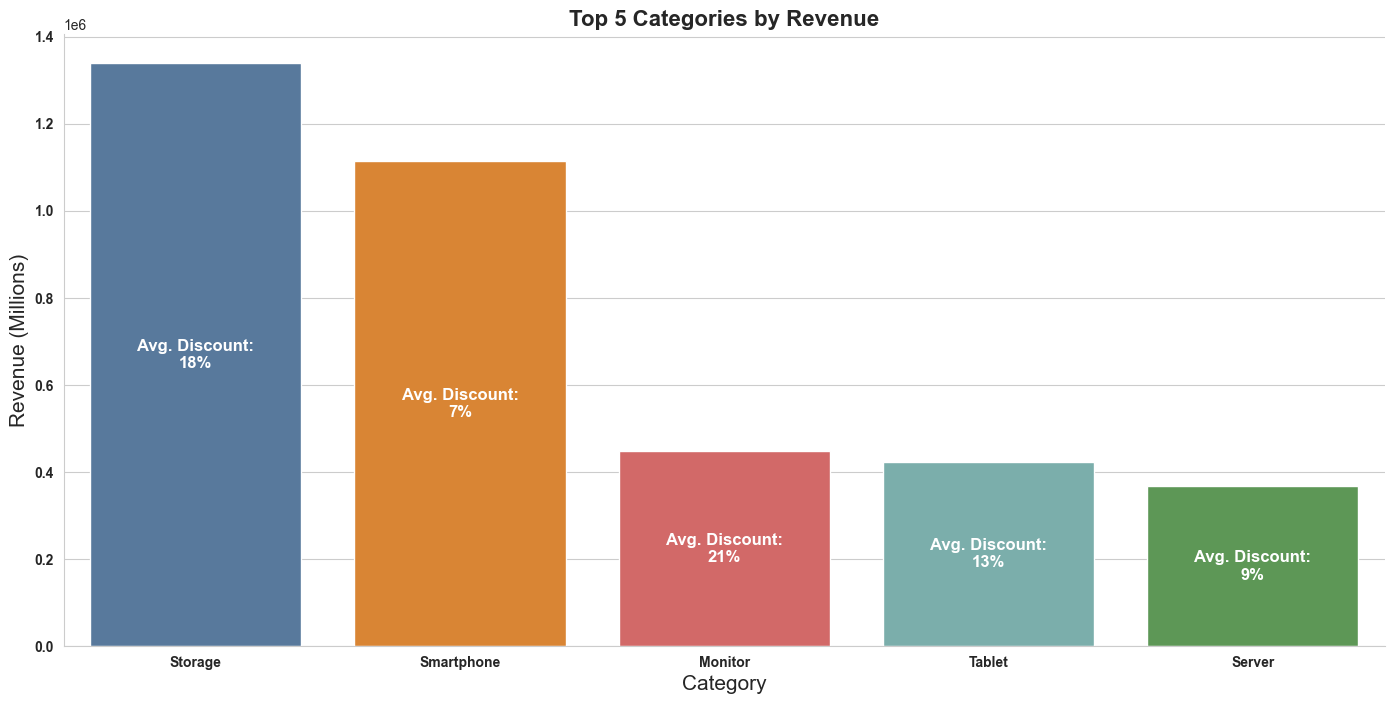

In [85]:
sns.set_style('whitegrid')

# Create the bar plot
ax = sns.catplot(
    data=top_5_cat,
    y='total_revenue',
    x='category',
    kind='bar',
    hue='category',
    palette=palette,
    height=7,
    aspect=2
)

# Add title and axis labels
plt.title("Top 5 Categories by Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Category", fontsize=15)
plt.ylabel("Revenue (Millions)", fontsize=15)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Annotate bars with discount rates
for i, bar in enumerate(ax.ax.patches):
    discount = top_5_cat.iloc[i]['average_discount_rate']
    height = bar.get_height()
    ax.ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,  # Middle of the bar
        f'Avg. Discount:\n{discount * 100:.0f}%',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='white'  # better visibility inside blue bar
    )
plt.savefig('/Users/yazdan/Desktop/plots/top_5_cat_by_rev.png', dpi=300, bbox_inches='tight')

In [58]:
category_agg=ol_p_df.groupby('category').agg(
    total_sold_quantity=('qty','sum'),
    total_revenue=('total_sale_price','sum'),
    average_discount_rate=('discount_rate','mean'),
    
                               ).nlargest(20,'total_sold_quantity')

In [59]:
category_agg

,total_sold_quantity,total_revenue,average_discount_rate
category,,,
storage,9528,1338825.12,0.179485
other,8053,640726.35,0.188855
ram,3341,315933.05,0.142146
cable,2647,42784.57,0.341685
protection,2644,49694.48,0.268759
case,2206,64680.93,0.372535
adapter,2188,80761.01,0.205030
headset,2008,206506.70,0.306051
smartphone,1938,1113919.51,0.067329


In [60]:
top_5_cat_sold=category_agg.loc[['storage','ram','cable','protection','case']]

In [61]:
top_5_cat_sold.index=top_5_cat_sold.index.str.capitalize()

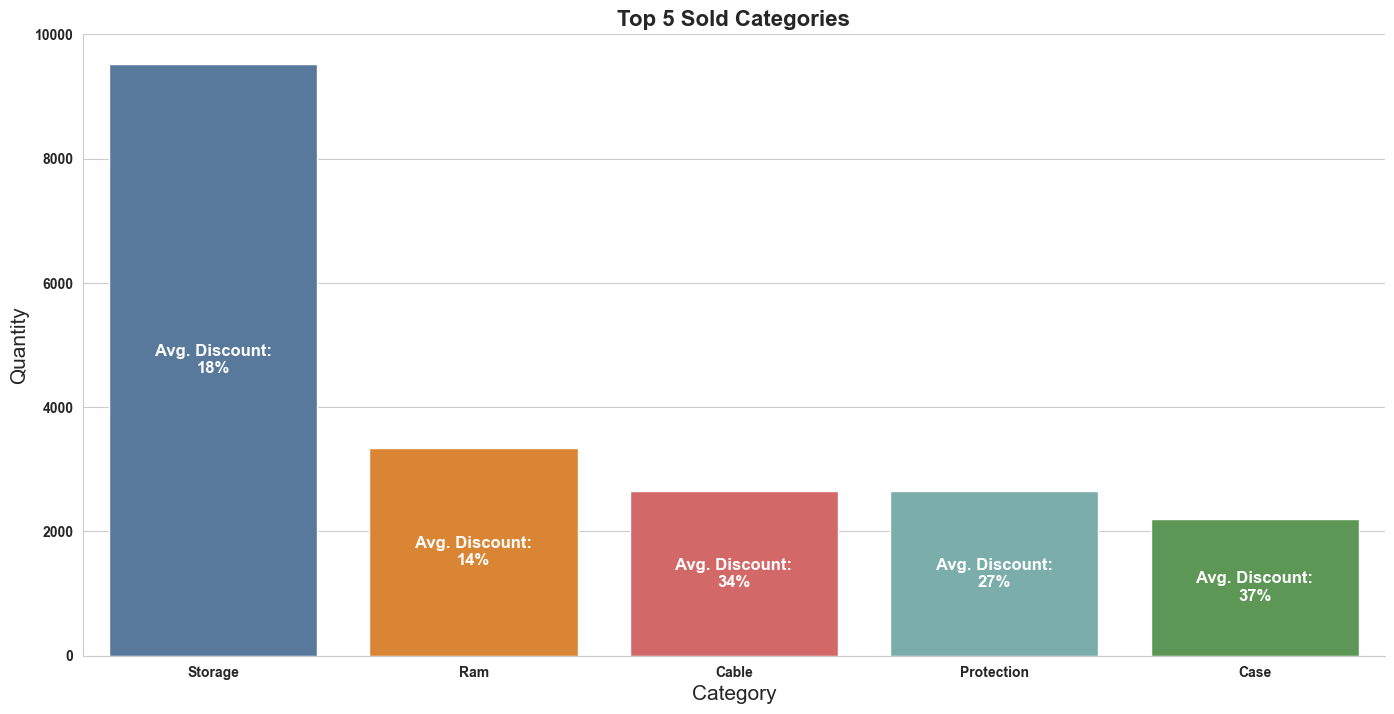

In [86]:
sns.set_style('whitegrid')

# Create the bar plot
ax = sns.catplot(
    data=top_5_cat_sold,
    y='total_sold_quantity',
    x='category',
    kind='bar',
    hue='category',
    palette=palette,
    height=7,
    aspect=2
)

# Add title and axis labels
plt.title("Top 5 Sold Categories", fontsize=16, fontweight='bold')
plt.xlabel("Category", fontsize=15)
plt.ylabel("Quantity", fontsize=15)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Annotate bars with discount rates
for i, bar in enumerate(ax.ax.patches):
    discount = top_5_cat_sold.iloc[i]['average_discount_rate']
    height = bar.get_height()
    ax.ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,  # Middle of the bar
        f'Avg. Discount:\n{discount * 100:.0f}%',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='white'  # better visibility inside blue bar
    )

plt.savefig('/Users/yazdan/Desktop/plots/top_5_cat_sold.png', dpi=300, bbox_inches='tight')